# Desafio: Analisando Dados de Preços de Casas nos EUA
**Dataset:** House Prices - Advanced Regression Techniques (Kaggle)  
**Objetivo:** Realizar a análise exploratória dos dados e a engenharia de features para preparar o dataset para os modelos de Machine Learning.
---

## Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

---
### 1. Análise exploratória de dados


### 1.1 Carregando o dataset

In [2]:
df = pd.read_csv("house-prices-advanced-regression-techniques/train.csv")

print(f"O dataset tem {df.shape[0]} linhas e {df.shape[1]} colunas")
df.head()

O dataset tem 1460 linhas e 81 colunas


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 1.2 Identificação das variáveis


In [3]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variáveis numéricas: {len(numeric_cols)}")
print(f"Variáveis categóricas: {len(categorical_cols)}")

print(f"\nNuméricas: {numeric_cols}")
print(f"\nCategóricas: {categorical_cols}")

Variáveis numéricas: 38
Variáveis categóricas: 43

Numéricas: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categóricas: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'Ki

### 1.3 Estatísticas descritivas


In [4]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [5]:
df[categorical_cols].describe().T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


### 1.4 Valores faltantes


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Faltantes': missing,
    'Porcentagem': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Faltantes'] > 0].sort_values(by='Faltantes', ascending=False)

print(f"{len(missing_df)} colunas possuem valores faltantes\n")
missing_df

19 colunas possuem valores faltantes



,Faltantes,Porcentagem
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


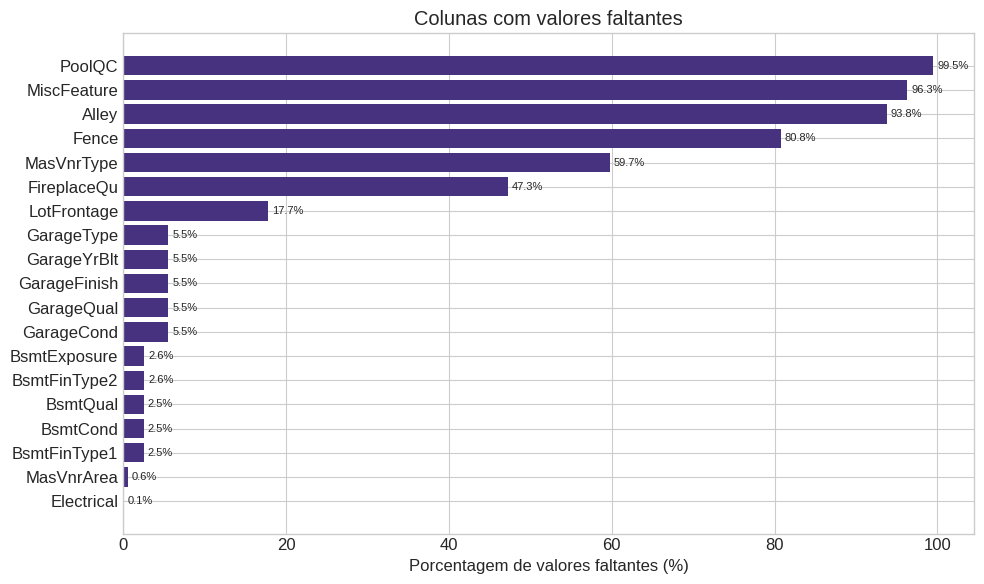

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(missing_df.index[::-1], missing_df['Porcentagem'][::-1])
ax.set_xlabel('Porcentagem de valores faltantes (%)')
ax.set_title('Colunas com valores faltantes')

for i, (val, name) in enumerate(zip(missing_df['Porcentagem'][::-1], missing_df.index[::-1])):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 1.5 Distribuição das variáveis


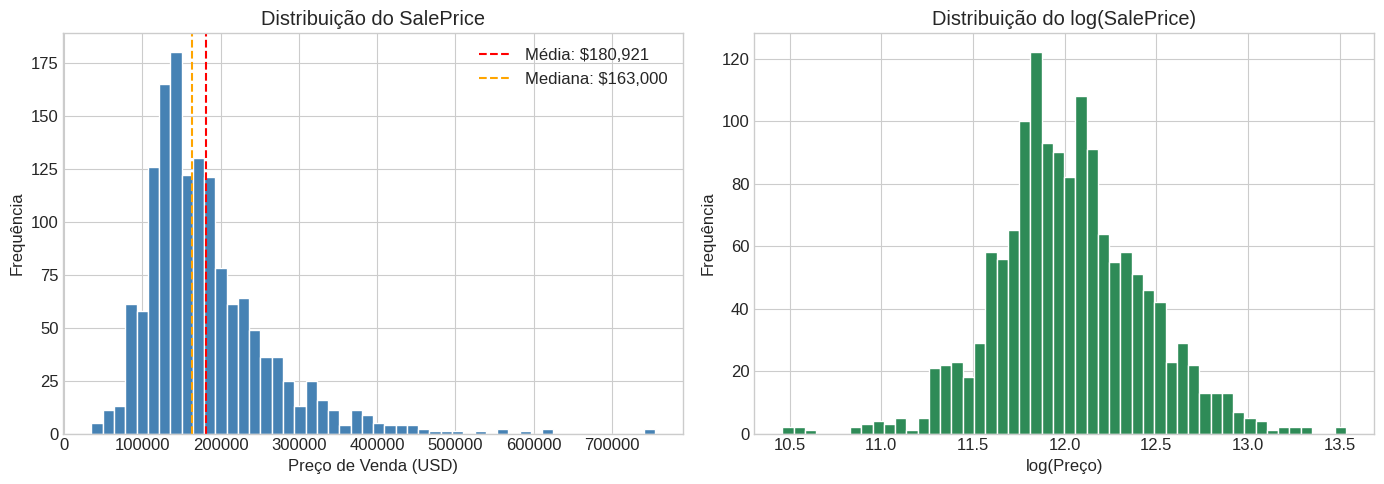

Assimetria (skewness): 1.88
Curtose (kurtosis): 6.54

A distribuição é assimétrica para direita, ou seja, a maioria das casas custa abaixo da média.
Aplicando log a distribuição fica mais próxima de uma normal.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do SalePrice')
axes[0].set_xlabel('Preço de Venda (USD)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f"Média: ${df['SalePrice'].mean():,.0f}")
axes[0].axvline(df['SalePrice'].median(), color='orange', linestyle='--', label=f"Mediana: ${df['SalePrice'].median():,.0f}")
axes[0].legend()

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Distribuição do log(SalePrice)')
axes[1].set_xlabel('log(Preço)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

print(f"Assimetria (skewness): {df['SalePrice'].skew():.2f}")
print(f"Curtose (kurtosis): {df['SalePrice'].kurtosis():.2f}")
print("\nA distribuição é assimétrica para direita, ou seja, a maioria das casas custa abaixo da média.")
print("Aplicando log a distribuição fica mais próxima de uma normal.")

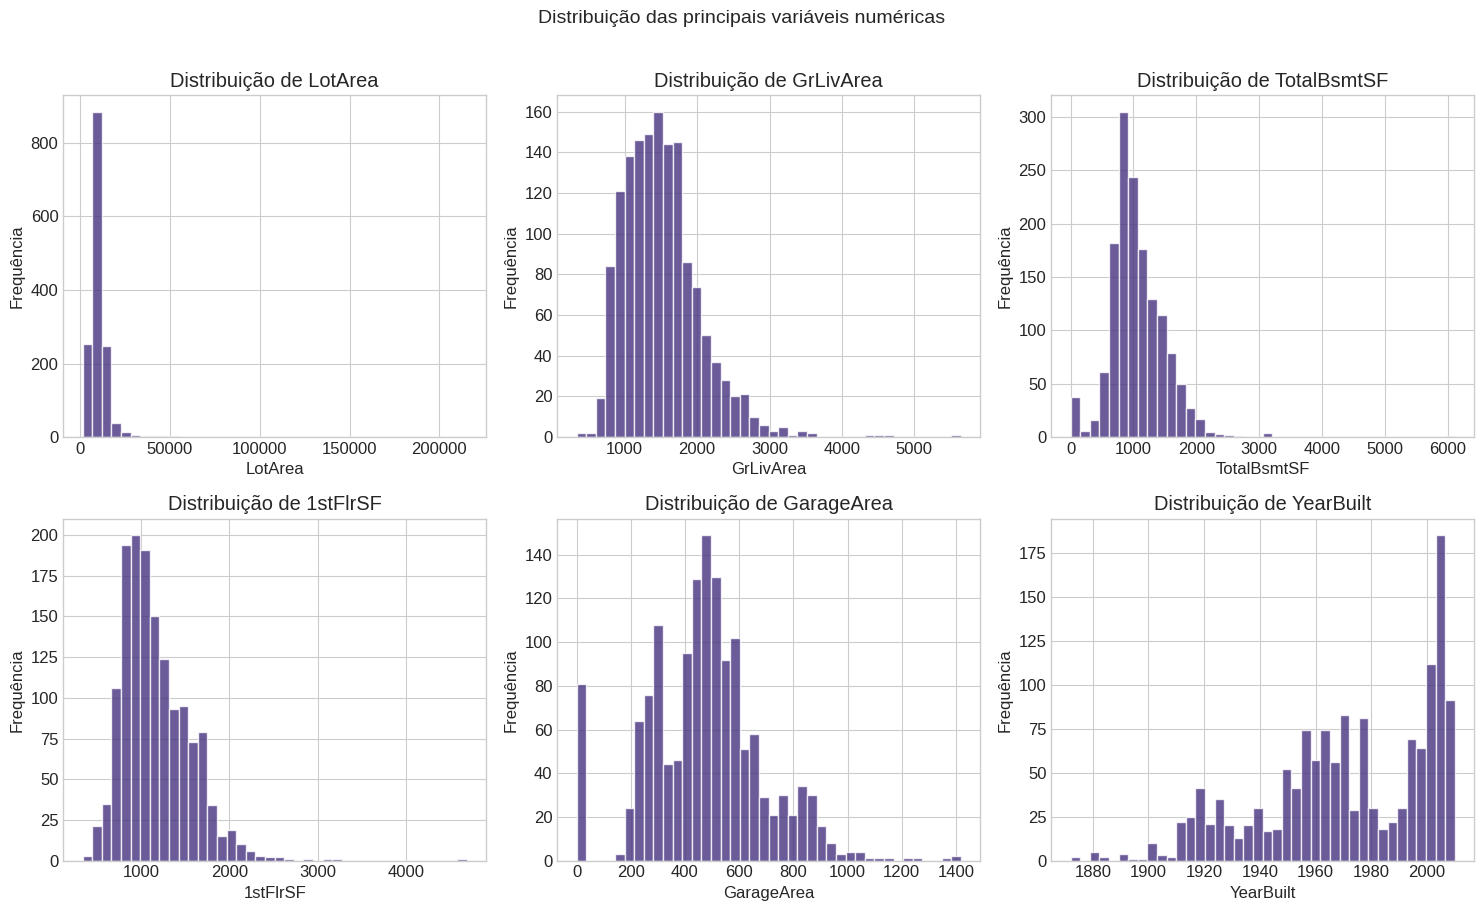

In [9]:
vars_importantes = ['LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(vars_importantes):
    axes[i].hist(df[col].dropna(), bins=40, edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribuição de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')

plt.suptitle('Distribuição das principais variáveis numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 1.6 Análise de outliers


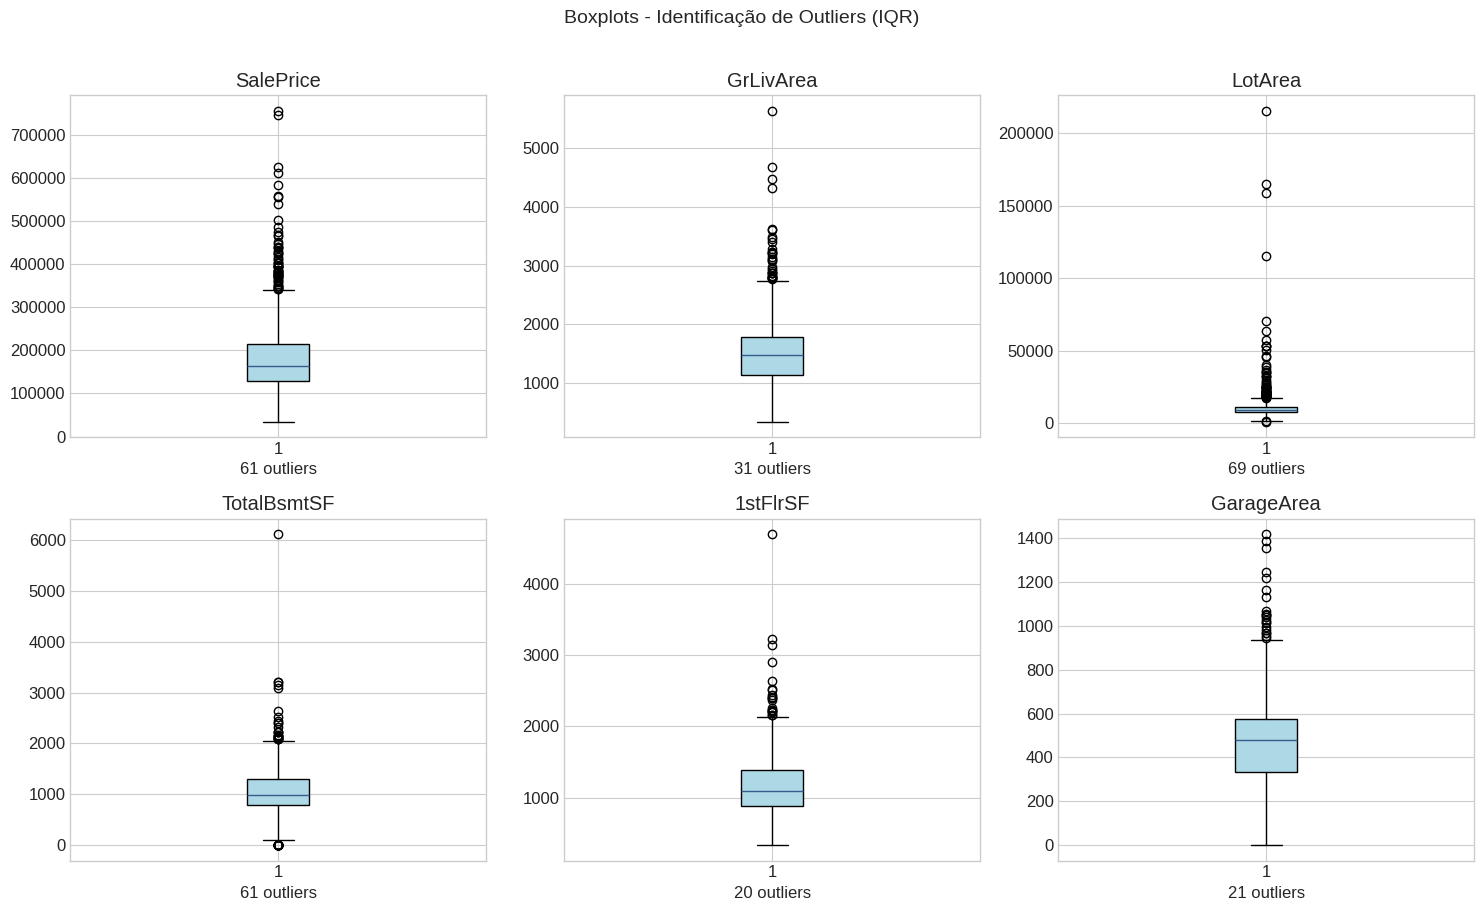

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

outlier_cols = ['SalePrice', 'GrLivArea', 'LotArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea']

for i, col in enumerate(outlier_cols):
    data = df[col].dropna()
    axes[i].boxplot(data, patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'{col}')

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    axes[i].set_xlabel(f'{n_outliers} outliers')

plt.suptitle('Boxplots - Identificação de Outliers (IQR)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
print("Resumo de outliers (método IQR):")
print(f"{'Variável':<18} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Outliers':>10}")
print("-" * 60)

for col in outlier_cols:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    print(f"{col:<18} {Q1:>10.1f} {Q3:>10.1f} {IQR:>10.1f} {n_outliers:>10}")

Resumo de outliers (método IQR):
Variável                   Q1         Q3        IQR   Outliers
------------------------------------------------------------
SalePrice            129975.0   214000.0    84025.0         61
GrLivArea              1129.5     1776.8      647.2         31
LotArea                7553.5    11601.5     4048.0         69
TotalBsmtSF             795.8     1298.2      502.5         61
1stFlrSF                882.0     1391.2      509.2         20
GarageArea              334.5      576.0      241.5         21


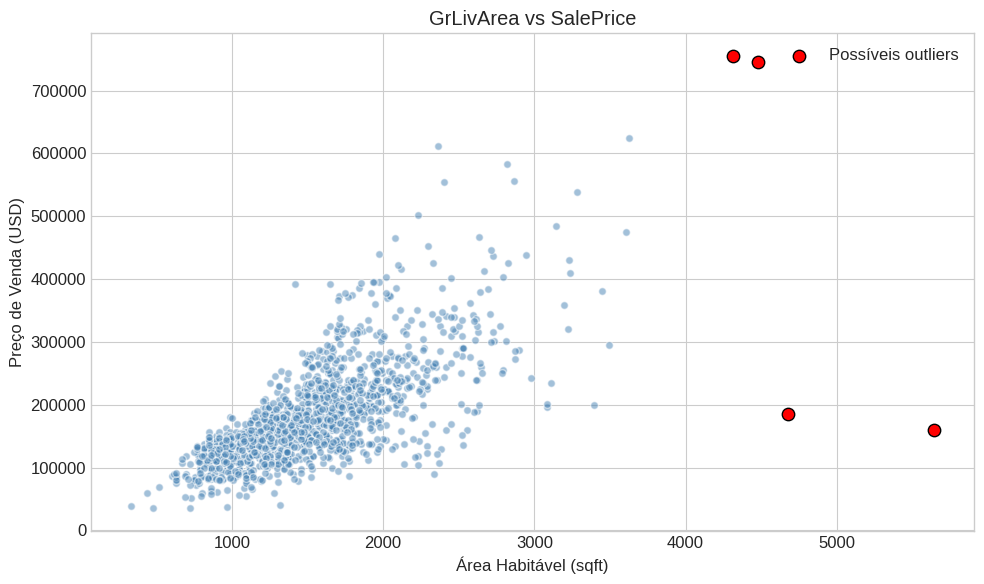

Existem 4 casas com área > 4000 sqft que parecem ser outliers.


In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, color='steelblue', edgecolors='white', s=30)

outliers = df['GrLivArea'] > 4000
plt.scatter(df.loc[outliers, 'GrLivArea'], df.loc[outliers, 'SalePrice'],
           color='red', s=80, edgecolors='black', label='Possíveis outliers')

plt.xlabel('Área Habitável (sqft)')
plt.ylabel('Preço de Venda (USD)')
plt.title('GrLivArea vs SalePrice')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Existem {outliers.sum()} casas com área > 4000 sqft que parecem ser outliers.")

### 1.7 Correlação entre as variáveis


In [13]:
corr_matrix = df[numeric_cols].corr()
corr_saleprice = corr_matrix['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print("Variáveis mais correlacionadas com SalePrice:")
print("-" * 45)
for col, val in corr_saleprice.head(15).items():
    print(f"  {col:<20} {val:>+.4f}")

Variáveis mais correlacionadas com SalePrice:
---------------------------------------------
  OverallQual          +0.7910
  GrLivArea            +0.7086
  GarageCars           +0.6404
  GarageArea           +0.6234
  TotalBsmtSF          +0.6136
  1stFlrSF             +0.6059
  FullBath             +0.5607
  TotRmsAbvGrd         +0.5337
  YearBuilt            +0.5229
  YearRemodAdd         +0.5071
  GarageYrBlt          +0.4864
  MasVnrArea           +0.4775
  Fireplaces           +0.4669
  BsmtFinSF1           +0.3864
  LotFrontage          +0.3518


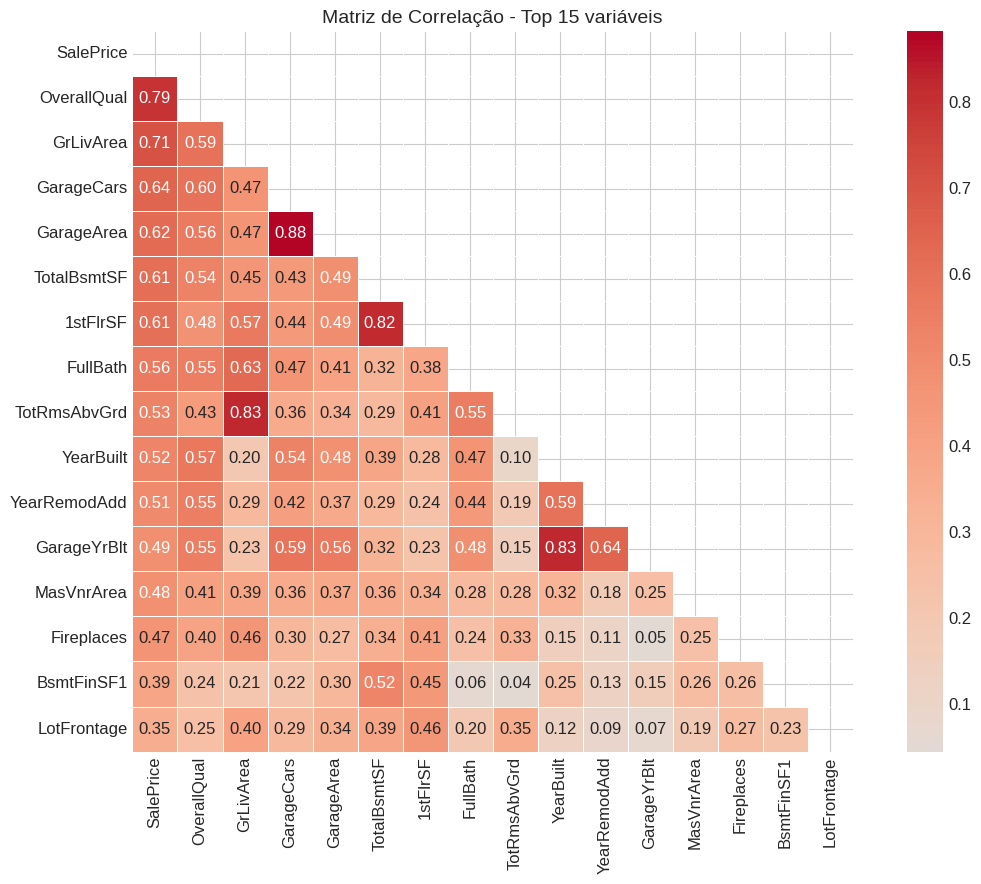

OverallQual (qualidade geral) e GrLivArea (área habitável) são as variáveis com maior correlação positiva com o preço.
GarageCars e GarageArea tem alta correlação entre si, o que indica multicolinearidade.


In [14]:
top_cols = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(16).index.tolist()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(df[top_cols].corr(), dtype=bool))

sns.heatmap(df[top_cols].corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)

ax.set_title('Matriz de Correlação - Top 15 variáveis', fontsize=14)
plt.tight_layout()
plt.show()

print("OverallQual (qualidade geral) e GrLivArea (área habitável) são as variáveis com maior correlação positiva com o preço.")
print("GarageCars e GarageArea tem alta correlação entre si, o que indica multicolinearidade.")

---
### 2. Featuring Engineering (Felipe)


In [15]:
df_fe = df.copy()

### 2.1 Tratamento de valores faltantes
- **Categóricas**: preenchemos com a moda (valor mais frequente)
- **Numéricas**: preenchemos com a mediana (mais robusta a outliers que a média)

In [16]:
cols_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for col in cols_none:
    if col in df_fe.columns:
        df_fe[col] = df_fe[col].fillna('None')

for col in categorical_cols:
    if df_fe[col].isnull().sum() > 0:
        df_fe[col] = df_fe[col].fillna(df_fe[col].mode()[0])

for col in numeric_cols:
    if df_fe[col].isnull().sum() > 0:
        df_fe[col] = df_fe[col].fillna(df_fe[col].median())

print(f"Valores faltantes restantes: {df_fe.isnull().sum().sum()}")

Valores faltantes restantes: 0


### 2.2 Criação de novas features
| Nova variável | Como é calculada | Por que |
|---|---|---|
| TotalAreaSF | 1stFlrSF + 2ndFlrSF + TotalBsmtSF | Área total construída da casa |
| HouseAge | YrSold - YearBuilt | Idade da casa quando foi vendida |
| RemodAge | YrSold - YearRemodAdd | Tempo desde a última reforma |
| TotalBath | FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath | Número total de banheiros |
| TotalPorchSF | Soma de todas as áreas de varanda | Área total de varanda |
| HasPool | 1 se tem piscina, 0 se não | Indicador binário |
| HasGarage | 1 se tem garagem, 0 se não | Indicador binário |

In [17]:
df_fe['TotalAreaSF'] = df_fe['1stFlrSF'] + df_fe['2ndFlrSF'] + df_fe['TotalBsmtSF']
df_fe['HouseAge'] = df_fe['YrSold'] - df_fe['YearBuilt']
df_fe['RemodAge'] = df_fe['YrSold'] - df_fe['YearRemodAdd']
df_fe['TotalBath'] = (df_fe['FullBath'] + 0.5 * df_fe['HalfBath'] +
                      df_fe['BsmtFullBath'] + 0.5 * df_fe['BsmtHalfBath'])
df_fe['TotalPorchSF'] = (df_fe['OpenPorchSF'] + df_fe['EnclosedPorch'] +
                         df_fe['3SsnPorch'] + df_fe['ScreenPorch'])
df_fe['HasPool'] = (df_fe['PoolArea'] > 0).astype(int)
df_fe['HasGarage'] = (df_fe['GarageArea'] > 0).astype(int)

new_features = ['TotalAreaSF', 'HouseAge', 'RemodAge', 'TotalBath', 'TotalPorchSF', 'HasPool', 'HasGarage']

print("Correlação das novas features com SalePrice:")
print("-" * 40)
for feat in new_features:
    corr = df_fe[feat].corr(df_fe['SalePrice'])
    print(f"  {feat:<18} {corr:>+.4f}")

Correlação das novas features com SalePrice:
----------------------------------------
  TotalAreaSF        +0.7823
  HouseAge           -0.5234
  RemodAge           -0.5091
  TotalBath          +0.6317
  TotalPorchSF       +0.1957
  HasPool            +0.0937
  HasGarage          +0.2368


### 2.3 Codificação de variáveis categóricas


In [18]:
le = LabelEncoder()

for col in categorical_cols:
    df_fe[col] = le.fit_transform(df_fe[col].astype(str))

print(f"{len(categorical_cols)} variáveis categóricas codificadas")
print(f"\nExemplo (primeiras 5 linhas de algumas colunas):")
df_fe[categorical_cols[:5]].head()

43 variáveis categóricas codificadas

Exemplo (primeiras 5 linhas de algumas colunas):


,MSZoning,Street,Alley,LotShape,LandContour
0,3,1,1,3,3
1,3,1,1,3,3
2,3,1,1,0,3
3,3,1,1,0,3
4,3,1,1,0,3


### 2.4 Normalização


In [19]:
all_numeric = df_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
cols_to_scale = [col for col in all_numeric if col not in ['Id', 'SalePrice']]

scaler = StandardScaler()
df_fe[cols_to_scale] = scaler.fit_transform(df_fe[cols_to_scale])

print(f"{len(cols_to_scale)} variáveis normalizadas")
print(f"\nVerificação (média e desvio padrão devem ser ~0 e ~1):")
df_fe[cols_to_scale[:5]].describe().loc[['mean', 'std']].round(4)

86 variáveis normalizadas

Verificação (média e desvio padrão devem ser ~0 e ~1):


,MSSubClass,MSZoning,LotFrontage,LotArea,Street
mean,-0.0000,-0.0000,0.0000,-0.0000,0.0000
std,1.0003,1.0003,1.0003,1.0003,1.0003


### 2.5 Seleção de variáveis importantes


In [20]:
corr_target = df_fe.corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)

threshold = 0.3
selected = corr_target[corr_target >= threshold]

print(f"Variáveis com |correlação| >= {threshold}: {len(selected)} de {len(corr_target)}")
print(f"\n{'Variável':<25} {'Correlação':>12}")
print("-" * 38)
for feat, val in selected.items():
    real_corr = df_fe[feat].corr(df_fe['SalePrice'])
    print(f"  {feat:<23} {real_corr:>+.4f}")

Variáveis com |correlação| >= 0.3: 30 de 87

Variável                    Correlação
--------------------------------------
  OverallQual             +0.7910
  TotalAreaSF             +0.7823
  GrLivArea               +0.7086
  GarageCars              +0.6404
  ExterQual               -0.6369
  TotalBath               +0.6317
  GarageArea              +0.6234
  TotalBsmtSF             +0.6136
  1stFlrSF                +0.6059
  BsmtQual                -0.5937
  KitchenQual             -0.5892
  FullBath                +0.5607
  TotRmsAbvGrd            +0.5337
  HouseAge                -0.5234
  YearBuilt               +0.5229
  RemodAge                -0.5091
  YearRemodAdd            +0.5071
  MasVnrArea              +0.4726
  Fireplaces              +0.4669
  GarageYrBlt             +0.4668
  GarageFinish            -0.4257
  GarageType              -0.4153
  HeatingQC               -0.4002
  BsmtFinSF1              +0.3864
  Foundation              +0.3825
  LotFrontage             +

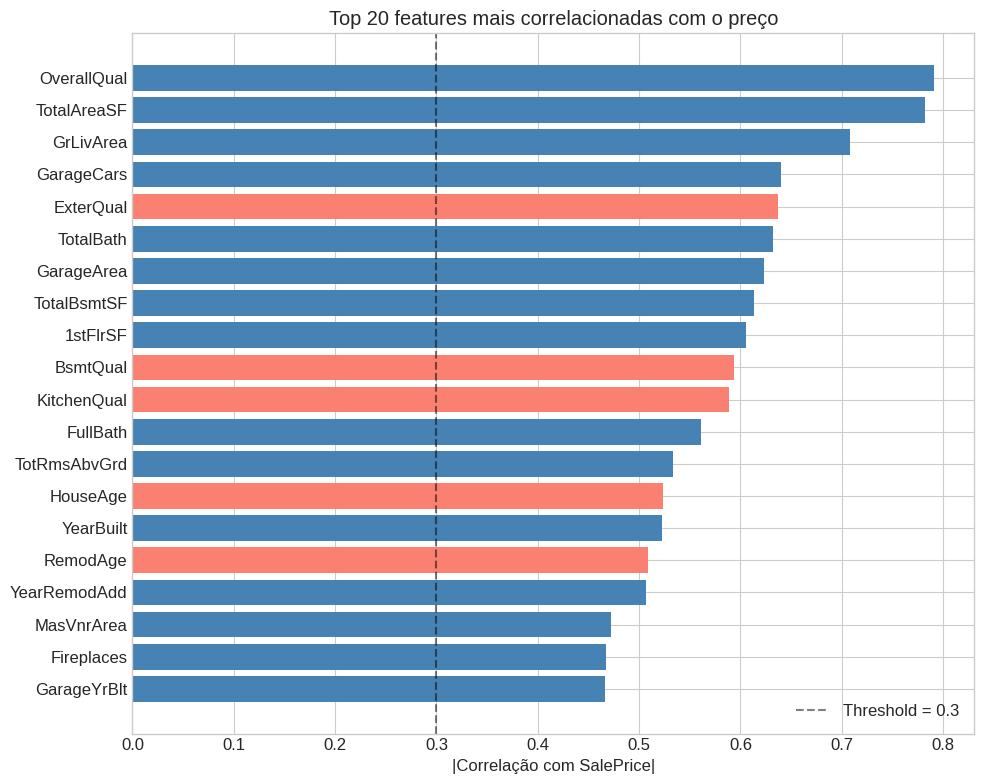

Azul = correlação positiva | Vermelho = correlação negativa


In [21]:
top20 = corr_target.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if df_fe[col].corr(df_fe['SalePrice']) > 0 else 'salmon' for col in top20.index]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_xlabel('|Correlação com SalePrice|')
ax.set_title('Top 20 features mais correlacionadas com o preço')
ax.axvline(x=threshold, color='black', linestyle='--', alpha=0.5, label=f'Threshold = {threshold}')
ax.legend()
plt.tight_layout()
plt.show()

print("Azul = correlação positiva | Vermelho = correlação negativa")

### 2.6 Salvando o dataset processado

In [22]:
df_fe.to_csv('dataset_processado.csv', index=False)

print("Resumo:")
print(f"  Dataset original:    {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"  Dataset processado:  {df_fe.shape[0]} linhas x {df_fe.shape[1]} colunas")
print(f"  Novas features:      {len(new_features)}")
print(f"  Valores faltantes:   0")
print(f"\nDataset salvo em 'dataset_processado.csv'")

Resumo:
  Dataset original:    1460 linhas x 81 colunas
  Dataset processado:  1460 linhas x 88 colunas
  Novas features:      7
  Valores faltantes:   0

Dataset salvo em 'dataset_processado.csv'


---
### 3. Aprendizagem Supervisionada


## Regressão Linear
### 3.1 Carregando o dataset

In [23]:
df = pd.read_csv("dataset_processado.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SaleType,SaleCondition,SalePrice,TotalAreaSF,HouseAge,RemodAge,TotalBath,TotalPorchSF,HasPool,HasGarage
0,1,0.073375,-0.045532,-0.220875,-0.207142,0.064238,0.024699,0.750731,0.314667,-0.02618,...,0.313867,0.208502,208500,-0.001277,-1.043259,-0.869941,1.642256,-0.248063,-0.069409,0.24236
1,2,-0.872563,-0.045532,0.460320,-0.091886,0.064238,0.024699,0.750731,0.314667,-0.02618,...,0.313867,0.208502,181500,-0.052407,-0.183465,0.390141,0.368581,-0.828163,-0.069409,0.24236
2,3,0.073375,-0.045532,-0.084636,0.073480,0.064238,0.024699,-1.378933,0.314667,-0.02618,...,0.313867,0.208502,223500,0.169157,-0.977121,-0.821476,1.642256,-0.428750,-0.069409,0.24236
3,4,0.309859,-0.045532,-0.447940,-0.096897,0.064238,0.024699,-1.378933,0.314667,-0.02618,...,0.313867,-3.426284,140000,-0.114493,1.800676,0.632464,-0.268257,2.091355,-0.069409,0.24236
4,5,0.073375,-0.045532,0.641972,0.375148,0.064238,0.024699,-1.378933,0.314667,-0.02618,...,0.313867,0.208502,250000,0.944631,-0.944052,-0.724547,1.642256,-0.029337,-0.069409,0.24236


### 3.2 Visualizando a estrutura dos dados

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 88 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   float64
 2   MSZoning       1460 non-null   float64
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   float64
 5   Street         1460 non-null   float64
 6   Alley          1460 non-null   float64
 7   LotShape       1460 non-null   float64
 8   LandContour    1460 non-null   float64
 9   Utilities      1460 non-null   float64
 10  LotConfig      1460 non-null   float64
 11  LandSlope      1460 non-null   float64
 12  Neighborhood   1460 non-null   float64
 13  Condition1     1460 non-null   float64
 14  Condition2     1460 non-null   float64
 15  BldgType       1460 non-null   float64
 16  HouseStyle     1460 non-null   float64
 17  OverallQual    1460 non-null   float64
 18  OverallC

### 3.3 Separarando X e y

In [25]:
target = 'SalePrice'

X = df.drop(target, axis=1)
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 87)
y shape: (1460,)


### 3.4 Divisão de treino/teste

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

### 3.5 Treinamento do modelo

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### 3.6 Predição

In [28]:
y_pred = model.predict(X_test)

### 3.7 Avaliação

In [29]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("---MÉTRICAS---")
print(f"RMSE: {rmse:}")
print(f"MAE: {mae:}")
print(f"R²: {r2:}")

---MÉTRICAS---
RMSE: 38196.025556624416
MAE: 20749.776282814364
R²: 0.8097947428943404


### 3.8 Interpretação dos coeficientes

In [30]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coeficiente": model.coef_
})

coef_df.sort_values(by="Coeficiente", ascending=False)

,Feature,Coeficiente
71,PoolArea,86629.805167
17,OverallQual,12970.224780
46,GrLivArea,10267.619205
80,TotalAreaSF,8413.746542
54,TotRmsAbvGrd,8179.842642
...,...,...
27,ExterQual,-5781.945708
30,BsmtQual,-5888.048402
53,KitchenQual,-6647.369263
72,PoolQC,-39482.486229


#### 3.9 Intercepto

In [31]:
print("Intercepto:", model.intercept_)

Intercepto: 181141.20442981322


### 3.10 Gráfico de dispersão

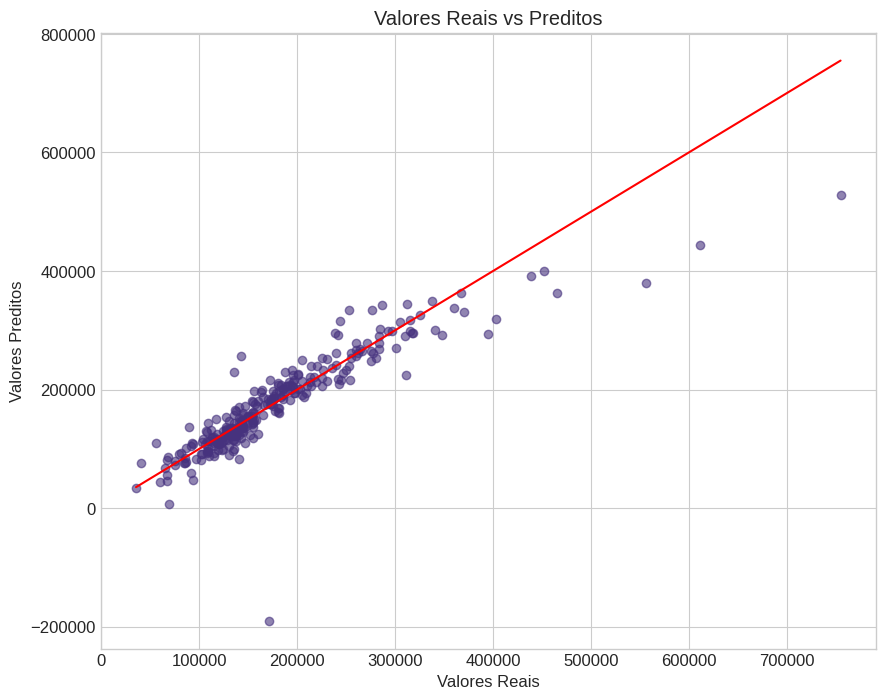

In [32]:
plt.figure(figsize=(10,8))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Valores Reais")
plt.ylabel("Valores Preditos")
plt.title("Valores Reais vs Preditos")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

### 3.11 Gráfico de Resíduos

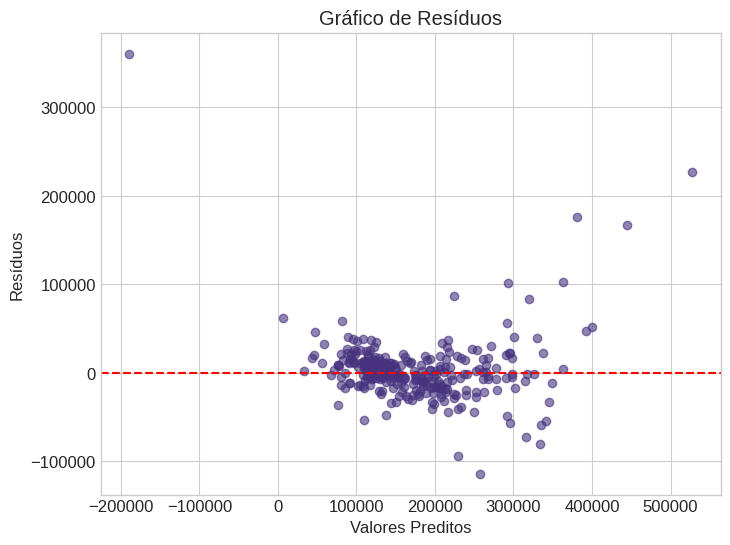

In [33]:
residuos = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuos, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Valores Preditos")
plt.ylabel("Resíduos")
plt.title("Gráfico de Resíduos")

plt.show()

### 3.12 Exemplo de boa e má previsão

In [34]:
resultados = pd.DataFrame({
    "Real": y_test,
    "Previsto": y_pred
})

resultados["Erro"] = abs(resultados["Real"] - resultados["Previsto"])

melhores = resultados.sort_values(by="Erro").head(1)

piores = resultados.sort_values(by="Erro", ascending=False).head(1)

print("EXEMPLO - BOA PREVISÃO")
print(f"Valor real:     $ {melhores['Real'].values[0]:,.2f}")
print(f"Valor previsto: $ {melhores['Previsto'].values[0]:,.2f}")
print(f"Erro:           $ {melhores['Erro'].values[0]:,.2f}")
print("\n")

print("EXEMPLO - ERRO ELEVADO")
print(f"Valor real:     $ {piores['Real'].values[0]:,.2f}")
print(f"Valor previsto: $ {piores['Previsto'].values[0]:,.2f}")
print(f"Erro:           $ {piores['Erro'].values[0]:,.2f}")

EXEMPLO - BOA PREVISÃO
Valor real:     $ 128,500.00
Valor previsto: $ 128,428.00
Erro:           $ 72.00


EXEMPLO - ERRO ELEVADO
Valor real:     $ 171,000.00
Valor previsto: $ -189,804.31
Erro:           $ 360,804.31


## Regressão Logística
### 3.13 Criando variável binária

In [35]:
mediana_preco = df['SalePrice'].median()

df['PrecoAlto'] = (df['SalePrice'] > mediana_preco).astype(int)

print(f"Mediana do preço: {mediana_preco}")
df[['SalePrice', 'PrecoAlto']].head()

Mediana do preço: 163000.0


,SalePrice,PrecoAlto
0,208500,1
1,181500,1
2,223500,1
3,140000,0
4,250000,1


### 3.14 Definindo X e y

In [36]:
X = df.drop(['SalePrice', 'PrecoAlto'], axis=1)
y = df['PrecoAlto']

### 3.15 Train test split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 3.16 Treinando modelo

In [38]:
modelo_class = LogisticRegression(max_iter=1000)
modelo_class.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### 3.17 Previsões

In [39]:
y_pred = modelo_class.predict(X_test)

### 3.18 Métricas

In [40]:
acc = accuracy_score(y_test, y_pred)

print(f"Acurácia: {acc:.4f}")

Acurácia: 0.9521


### 3.19 Matriz de confusão

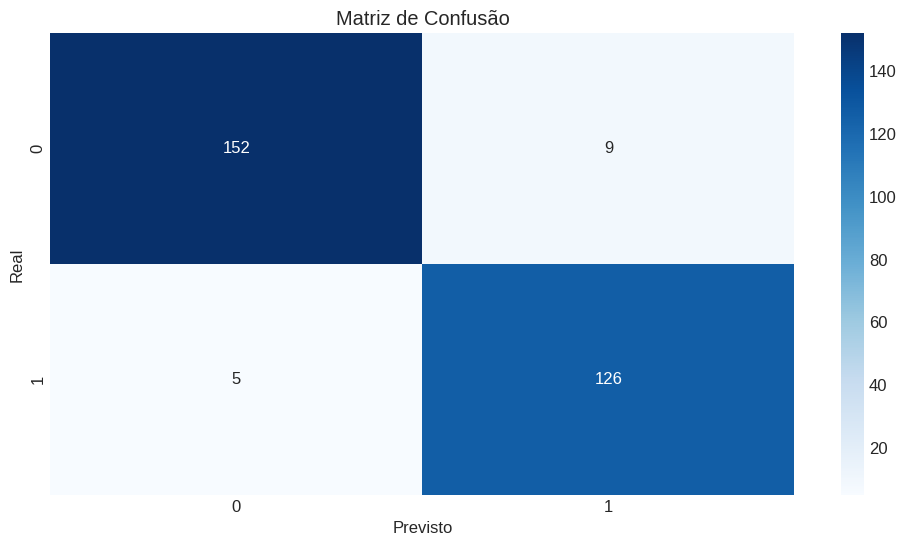

In [41]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

### 3.20 Classification Report

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96       161
           1       0.93      0.96      0.95       131

    accuracy                           0.95       292
   macro avg       0.95      0.95      0.95       292
weighted avg       0.95      0.95      0.95       292



---
### 4.1 Aprendizagem não supervisionada:
### Clusterização e redução de dimensionalidade (Karol)

### 4.1.1 Redução de Dimensionalidade

In [43]:
df = pd.read_csv('dataset_processado.csv')

X = df.drop(columns=['Id', 'SalePrice'])

pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(X)

df_pca = pd.DataFrame(data=componentes, columns=['Componente 1', 'Componente 2'])

variancia_explicada = pca.explained_variance_ratio_.sum() * 100
print(f"As duas componentes principais explicam {variancia_explicada:.2f}% da variância total.")

As duas componentes principais explicam 20.53% da variância total.


### 4.1.2 Clusterização

In [44]:
inercia = []
k_range = range(1, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_temp.fit(X)
    inercia.append(kmeans_temp.inertia_)

fig_elbow = go.Figure(data=go.Scatter(x=list(k_range), y=inercia, mode='lines+markers'))
fig_elbow.update_layout(
    title='Método do Cotovelo para Escolha do Número de Clusters (k)',
    xaxis_title='Número de Clusters (k)',
    yaxis_title='Inércia (WCSS)',
    plot_bgcolor='white'
)

fig_elbow.add_vline(x=4, line_dash="dash", line_color="red", annotation_text="k=4 sugerido")
fig_elbow.show()

In [45]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

df_pca['Cluster'] = kmeans.fit_predict(X).astype(str)

df_pca['SalePrice'] = df['SalePrice']
df_pca['OverallQual'] = df['OverallQual']
df_pca['GrLivArea'] = df['GrLivArea']

fig_clusters = px.scatter(
    df_pca,
    x='Componente 1',
    y='Componente 2',
    color='Cluster',
    hover_data=['SalePrice', 'OverallQual', 'GrLivArea'],
    title='Agrupamento de Casas nos EUA',
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.7
)

fig_clusters.update_layout(
    plot_bgcolor='white',
    legend_title_text='Grupos (K=4)'
)

fig_clusters.show()

---
### 4.2 Análise de Associação e Outlier

---
### 5. Métricas de avaliação e comparação